# Clasificación - Supervisado vs Clusterización
### Dataset "Iris"

##Importación de las librerías

In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

## Carga de los datos

In [3]:
data = pd.read_csv("/content/sample_data/Iris.csv", header = 0)

In [4]:
data = data.reset_index()
data.describe(include = "all")

,index,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,NaN,50
mean,74.500000,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,0.000000,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,37.250000,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,74.500000,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,111.750000,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


**Tenemos 3 tipos de especies**  

Sólo nos sirven las columnas de tamaño (anchura y longitud) de pétalos y sépalos y la columna de las especies.

Aunque los modelos de clasificación son modelos NO SUPERVISADOS, es decir, no existe una columna objetivo a "adivinar", vamos a utilizar este dataset como ejemplo y la columna "Species" como testigo para saber si la clasificación obtenida tiene un sentido real.

Eliminamos las dos columnas iniciales con el index y el Id

In [5]:
data = data.drop("index", axis=1)
data = data.drop("Id", axis=1)

# Análisis de datos y gráficas

### Histogramas

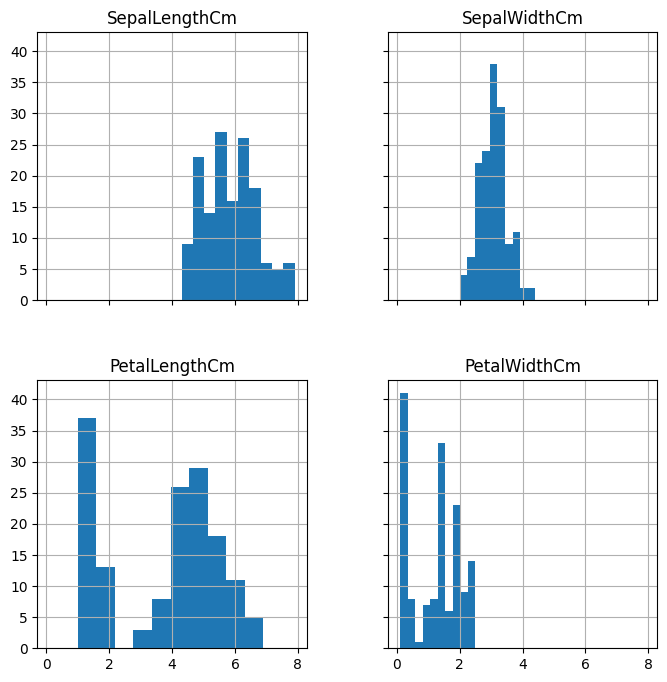

In [6]:
grafica = data.hist(
    column=["SepalLengthCm",
            "SepalWidthCm",
            "PetalLengthCm",
            "PetalWidthCm"
            ],
    figsize=(8, 8)
    # descomentar la línea de abajo para que usen los mismos ejes los 4 gráficos
    ,sharey=True, sharex=True
)

## Columna objetivo

Tenemos 50 flores de cada especie

In [7]:
data['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [8]:
data['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## Gráficos

Podemos crear distintos gráficos de pares

(1.5, 4.9)

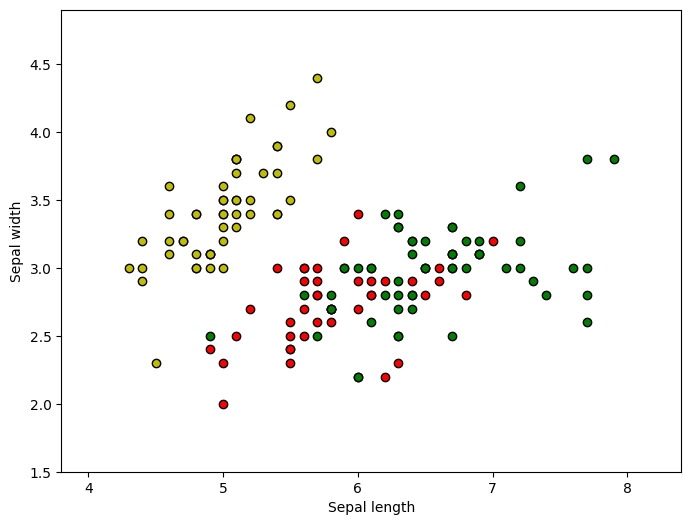

In [9]:
X = data.loc[:,["SepalLengthCm", "SepalWidthCm"]]
y = data["Species"]

x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5

plt.figure(2, figsize=(8, 6))
#plt.clf()
plt.scatter(X.iloc[:50, 0], X.iloc[:50, 1], c="y", edgecolor="k")
plt.scatter(X.iloc[50:100, 0], X.iloc[50:100, 1], c="r", edgecolor="k")
plt.scatter(X.iloc[100:150, 0], X.iloc[100:150, 1], c="g", edgecolor="k")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

Construimos una función que nos proporcione un gráfico para cada par de columnas

In [10]:
def grafica_pares(data, col_objetivo, col_x, col_y, nombre_x = None, nombre_y = None):
    # Verifica si se proporcionaron nombres personalizados, de lo contrario, usa los nombres de las columnas
    nombre_x = col_x if not nombre_x else nombre_x
    nombre_y = col_y if not nombre_y else nombre_y

    plt.figure(2, figsize=(8, 6))

    colores = ["y", "r", "g"]
    # Filtra las filas por categoría y utiliza la columna "Species" para colorear los puntos
    for flor, color in zip(data[col_objetivo].unique(), colores):
        plt.scatter(data.loc[data[col_objetivo] == flor, col_x],
                    data.loc[data[col_objetivo] == flor, col_y],
                    c=color, label=flor, edgecolor="k")

    # Poner nombres a los ejes
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)

    # Límites máximos y mínimos de los ejes
    plt.xlim(data[col_x].min()-0.5, data[col_x].max()+0.5)
    plt.ylim(data[col_y].min()-0.5, data[col_y].max()+0.5)

    plt.legend()  # Agrega la leyenda
    plt.show()

In [11]:
data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

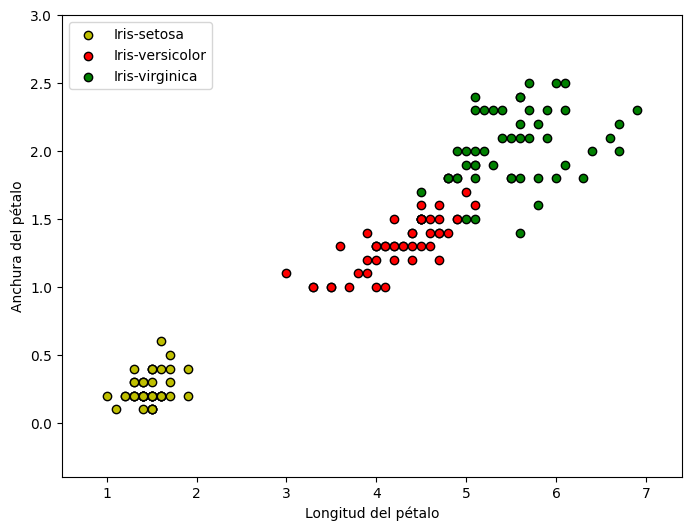

In [12]:
grafica_pares(data, "Species", "PetalLengthCm", "PetalWidthCm", "Longitud del pétalo", "Anchura del pétalo")

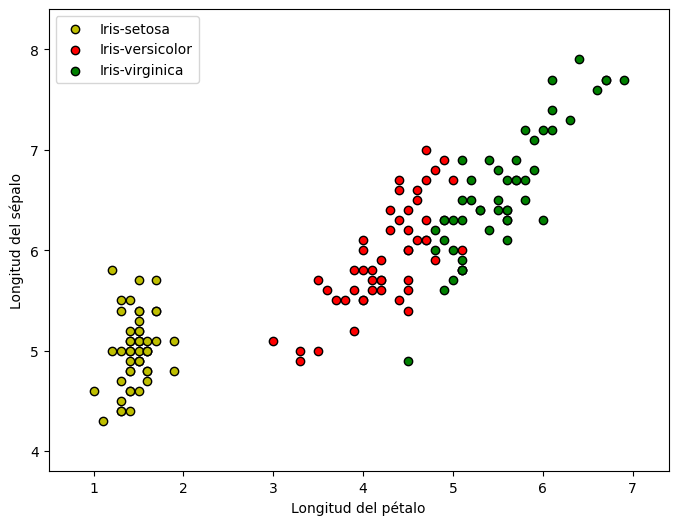

In [13]:
grafica_pares(data, "Species", "PetalLengthCm", "SepalLengthCm", "Longitud del pétalo", "Longitud del sépalo")

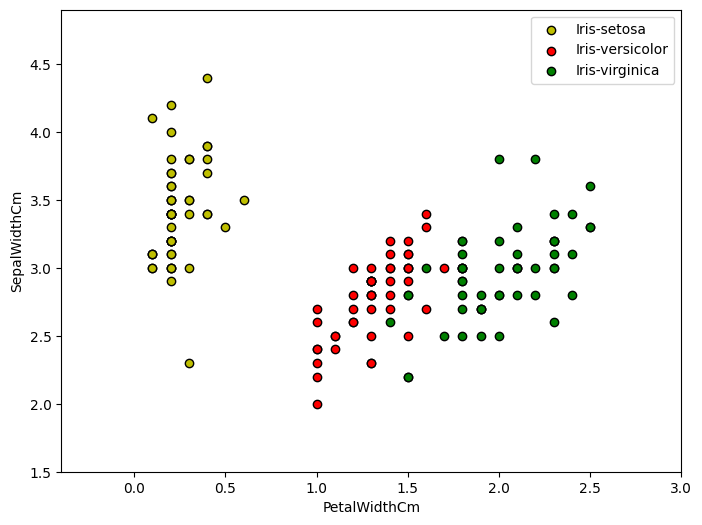

In [14]:
grafica_pares(data, "Species", "PetalWidthCm", "SepalWidthCm")

*A primera vista*, **Petal length** y **petal width** parecen **diverger** de la **distribución normal**.

In [15]:
import scipy.stats as stats

for param in ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]:
    z, pval = stats.normaltest(data[param])
    #print(z)
    if(pval < 0.055):
        print("%s tiene un valor p de %f - La distribución No es normal" % (param, pval))
    else:
        print("%s tiene un valor p de %f." % (param, pval))


SepalLengthCm tiene un valor p de 0.056824.
SepalWidthCm tiene un valor p de 0.167241.
PetalLengthCm tiene un valor p de 0.000000 - La distribución No es normal
PetalWidthCm tiene un valor p de 0.000000 - La distribución No es normal


### Matriz de correlación

Usamos el método de pearson para hallar las correlaciones.<br>
Es el método por defecto que hemos usado hasta ahora.<br>
Existen otros dos métodos de obtener la correlación.<br>
*method : {‘pearson’, ‘kendall’, ‘spearman’}*

In [16]:
data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [17]:
y = data["Species"]
X = data.drop('Species', axis = 1)
corr = X.corr(method="pearson")
display(corr)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


<Axes: >

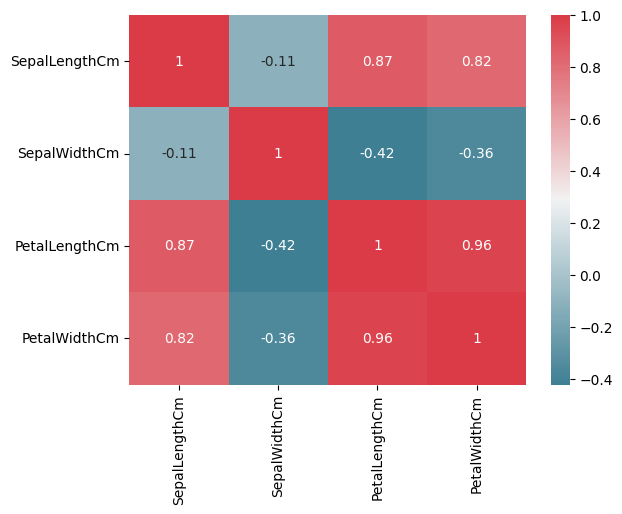

In [18]:
import seaborn as sns
sns.heatmap(corr, annot=True, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

### Interpretación
Encontramos:
+ una **alta correlación positiva** entre PetalWidth y PetalLength (**0.96**)
+ una **alta correlación positiva** entre PetalLength y SepalLength (**0.87**)
+ una **alta correlación positiva** entre PetalWidth y SepalLength (**0.81**)

Como tal, observamos correlaciones entre estos atributos principales: **PetalWidth**, **PetalLength** y **SepalLength**.

**SepalWidth** parece ser más independiente.

PCC es:
+ 1 es correlación lineal positiva total
+ 0 no es una correlación lineal
+ −1 es la correlación lineal negativa total

## Observación de la correlación en 3D

In [19]:
from mpl_toolkits.mplot3d import Axes3D

/tmp/ipython-input-20-434943828.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("Iris-virginica", 2)
/tmp/ipython-input-20-434943828.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.9)


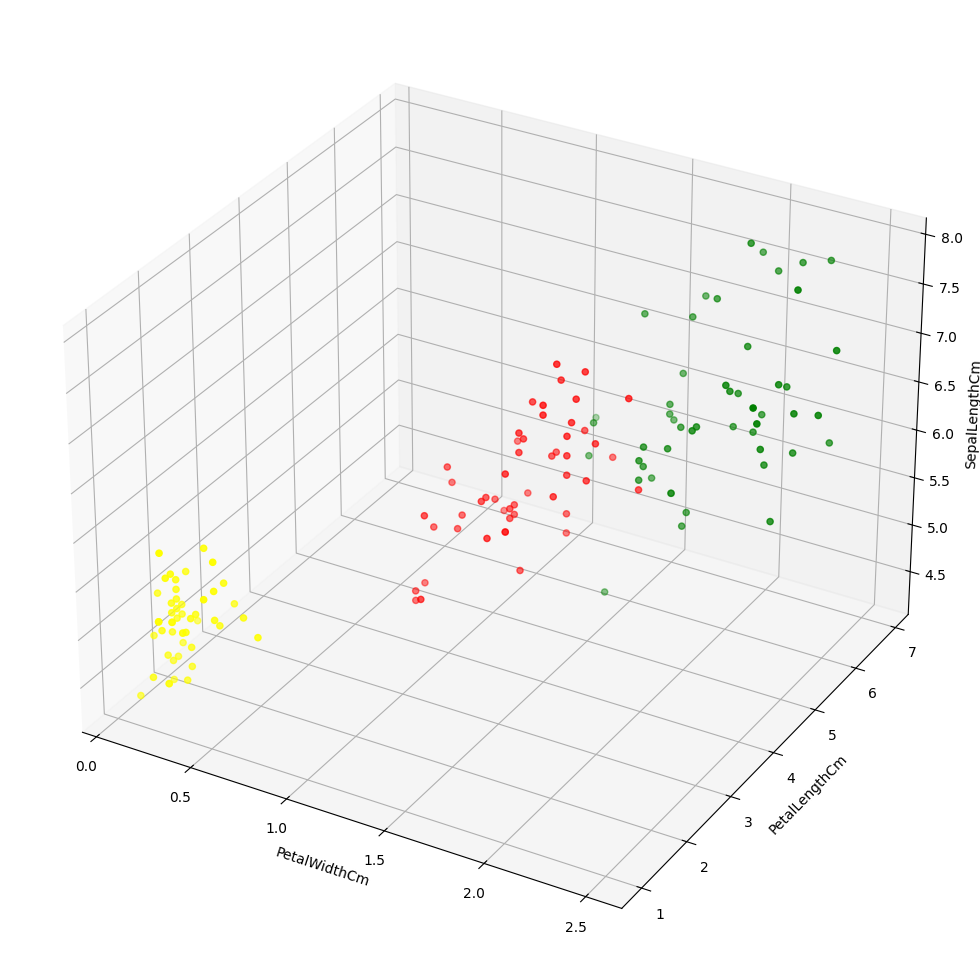

In [20]:
fig = plt.figure()
ax = fig.add_axes([0,0,1.7,2], projection='3d')
#ax = fig.add_subplot(111, projection='3d')
X = [data["PetalWidthCm"], data["PetalLengthCm"]]
n = 150
color_theme = np.array(["yellow", "red", "green"])
# Para poder coger el color correspondiente usando un índice en el array anterior
# tengo que convertir los nombres de las espacies en números
especies_num = data["Species"] \
            .replace("Iris-setosa", 0) \
            .replace("Iris-versicolor", 1) \
            .replace("Iris-virginica", 2)
ax.scatter(data["PetalWidthCm"], data["PetalLengthCm"], data["SepalLengthCm"], c = color_theme[especies_num])

ax.set_xlabel('PetalWidthCm')
ax.set_ylabel('PetalLengthCm')
ax.set_zlabel('SepalLengthCm')

plt.tight_layout(pad=0.9)
plt.show()

In [21]:
import plotly.graph_objs as go

# Función para pintar las reglas en 3D
def rotable_3d(x, col1, col2, col3, cat_col):
    datos = x.copy()
    # reseteo el índice de los datos originales
    datos.reset_index(inplace=True)

    # Crear el scatter plot en 3D con Plotly
    fig = go.Figure(data=[go.Scatter3d(
        x=datos[col1],
        y=datos[col2],
        z=datos[col3],
        mode='markers',
        marker=dict(
            size=10,
            color=datos[cat_col],  # Color según el valor de Lift
            colorscale='Viridis',  # Escala de color
            opacity=0.8
        ),
        text='<br>' + \
             col1 +": " + datos[col1].astype(str) + '<br>' + \
             col2 +": " + datos[col2].astype(str) + '<br>' + \
             col3 +": " + datos[col3].astype(str),
        hoverinfo='text'  # Mostrar texto en el menú emergente
    )])

    # Configuración del diseño del gráfico
    fig.update_layout(
        scene=dict(
            xaxis_title=col1,
            yaxis_title=col2,
            zaxis_title=col3,
        ),
        title='Scatter Plot 3D de Soporte vs Confianza vs Lift',
        width=800,
        height=1200,
    )

    # Mostrar el gráfico
    fig.show()

In [22]:
data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [23]:
data["Species"] = data["Species"].astype('category').cat.codes

In [24]:
rotable_3d(data, "PetalWidthCm", "PetalLengthCm", "SepalWidthCm", "Species")

# Data analysis - clasificación

In [25]:
from sklearn import linear_model

In [26]:
from sklearn import neighbors, datasets
from matplotlib.colors import ListedColormap

import math
import random
from numpy.random import permutation

Sustituimos los nombres de las especies por números

In [27]:
data["Species"].unique()

array([0, 1, 2], dtype=int8)

In [28]:
data["Species"] = data["Species"] \
            .replace("Iris-setosa", 0) \
            .replace("Iris-versicolor", 1) \
            .replace("Iris-virginica", 2)

In [29]:
data["Species"].unique()

array([0, 1, 2], dtype=int8)

In [30]:
from sklearn.model_selection import train_test_split

objetivo = "Species"
y = data[objetivo]
X = data.drop([objetivo], axis = 1)

# Regresión Logística

In [31]:
# Realizamos la particion dejando un 75% para entrenar y un 25% de test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state = 42)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Crear el modelo de regresión logística
modelo_logistico = LogisticRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo_logistico.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = modelo_logistico.predict(X_test)

# Evaluar el rendimiento del modelo
precision = accuracy_score(y_test, y_pred)
informe_clasificacion = classification_report(y_test, y_pred)

# Imprimir resultados
print(f"Precisión del modelo: {precision}")
print("Informe de clasificación:")
print(informe_clasificacion)

Precisión del modelo: 1.0
Informe de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def cuadro_matriz_confusion(y_real, y_pred):
    confusion = confusion_matrix(y_real, y_pred)
    categories = np.unique(y_real)

    fig, ax = plt.subplots()
    labels = ['Verdadero\nSetosa', 'Falso 1', 'Falso 2', 'Falso 0', 'Verdadero\nVersicolor', 'Falso 2', 'Falso 0', 'Falso 1', 'Verdadero\nVirginica']

    counts = ['{0:,}'.format(value) for value in confusion.flatten()]

    percentages = ['{0:.2%}'.format(value) for value in confusion.flatten() / np.sum(confusion)]

    labels = [f'{label}\n{count}\n{percentage}' for label, count, percentage in zip(labels, counts, percentages)]
    labels = np.asarray(labels).reshape(len(categories), len(categories))

    sns.heatmap(confusion, annot=labels, fmt='', cmap='Blues', xticklabels=categories, yticklabels=categories, ax=ax)
    plt.xlabel('Valores predichos')
    plt.ylabel('Valores reales')
    plt.title('Matriz de confusión')
    plt.show()

In [34]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[19,  0,  0],
       [ 0, 15,  0],
       [ 0,  0, 16]])

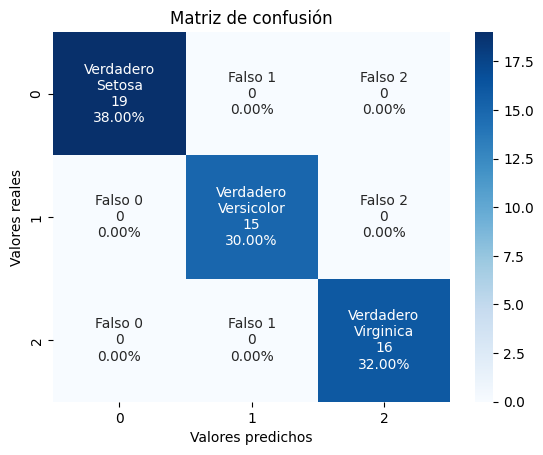

In [35]:
cuadro_matriz_confusion(y_test, y_pred)

## Normalización de los datos

In [36]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
data_sin_columnas = ss.fit_transform(X)
datos_normalizados = pd.DataFrame(data_sin_columnas, columns = X.columns)
X = datos_normalizados.copy()
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


In [37]:
# Realizamos la particion dejando un 75% para entrenar y un 25% de test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state = 42)

# KNeighborsClassifier

In [38]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn.fit(X_train, y_train)

# Use the model to predict labels for the test data
y_pred = knn.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[19,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 15]])

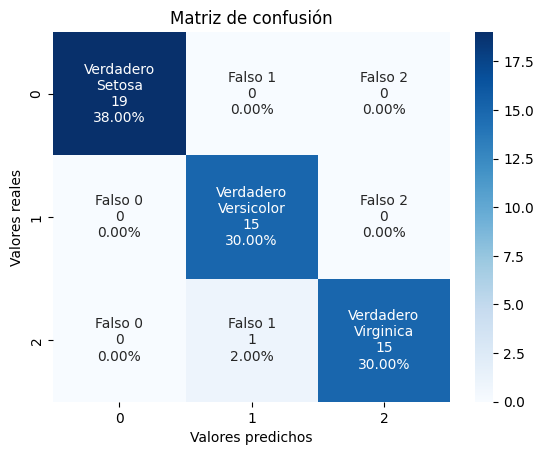

In [39]:
cuadro_matriz_confusion(y_test, y_pred)

In [41]:
# Realizar predicciones en el conjunto de prueba
y_pred = knn.predict(X_test)

# Evaluar el rendimiento del modelo
precision = accuracy_score(y_test, y_pred)
informe_clasificacion = classification_report(y_test, y_pred)

# Imprimir resultados
print(f"Precisión del modelo: {precision}")
print("Informe de clasificación:")
print(informe_clasificacion)

Precisión del modelo: 0.98
Informe de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



# Naïve Bayes

In [42]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [43]:
y_pred = gnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.96


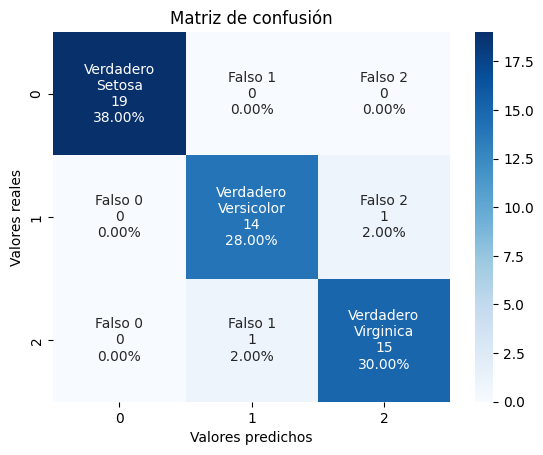

In [44]:
cuadro_matriz_confusion(y_test, y_pred)

# Árboles de decisión

In [45]:
from sklearn import tree
from sklearn.tree import export_graphviz
from six import StringIO

In [46]:
modelo = tree.DecisionTreeClassifier(class_weight=None,
                                     criterion='gini',
                                     max_depth=7,
                                     max_features=None,
                                     max_leaf_nodes=None,
                                     min_impurity_decrease=0.0,
                                     min_samples_leaf=1,
                                     min_samples_split=2,
                                     min_weight_fraction_leaf=0.0,
                                     random_state=None,
                                     splitter='best')

In [47]:
from sklearn.model_selection import cross_val_score
arbol = modelo.fit(X, y)
cross_val_score(arbol, X, y, cv=10)

array([1.        , 0.93333333, 1.        , 0.93333333, 0.93333333,
       0.86666667, 0.93333333, 0.93333333, 1.        , 1.        ])

In [48]:
arbol = modelo.fit(X_train, y_train)
y_pred = arbol.predict(X_test)
accuracy_score(y_test, y_pred)

0.96

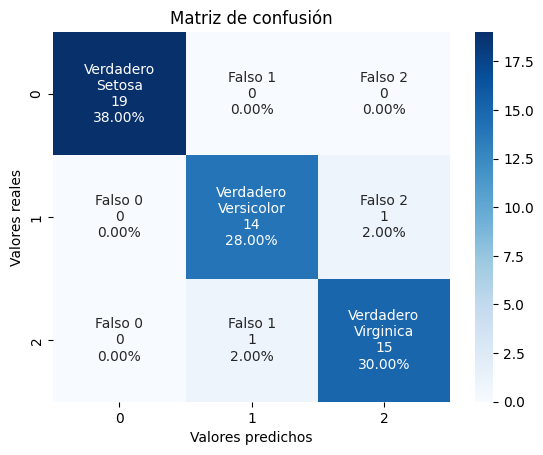

In [49]:
cuadro_matriz_confusion(y_test, y_pred)

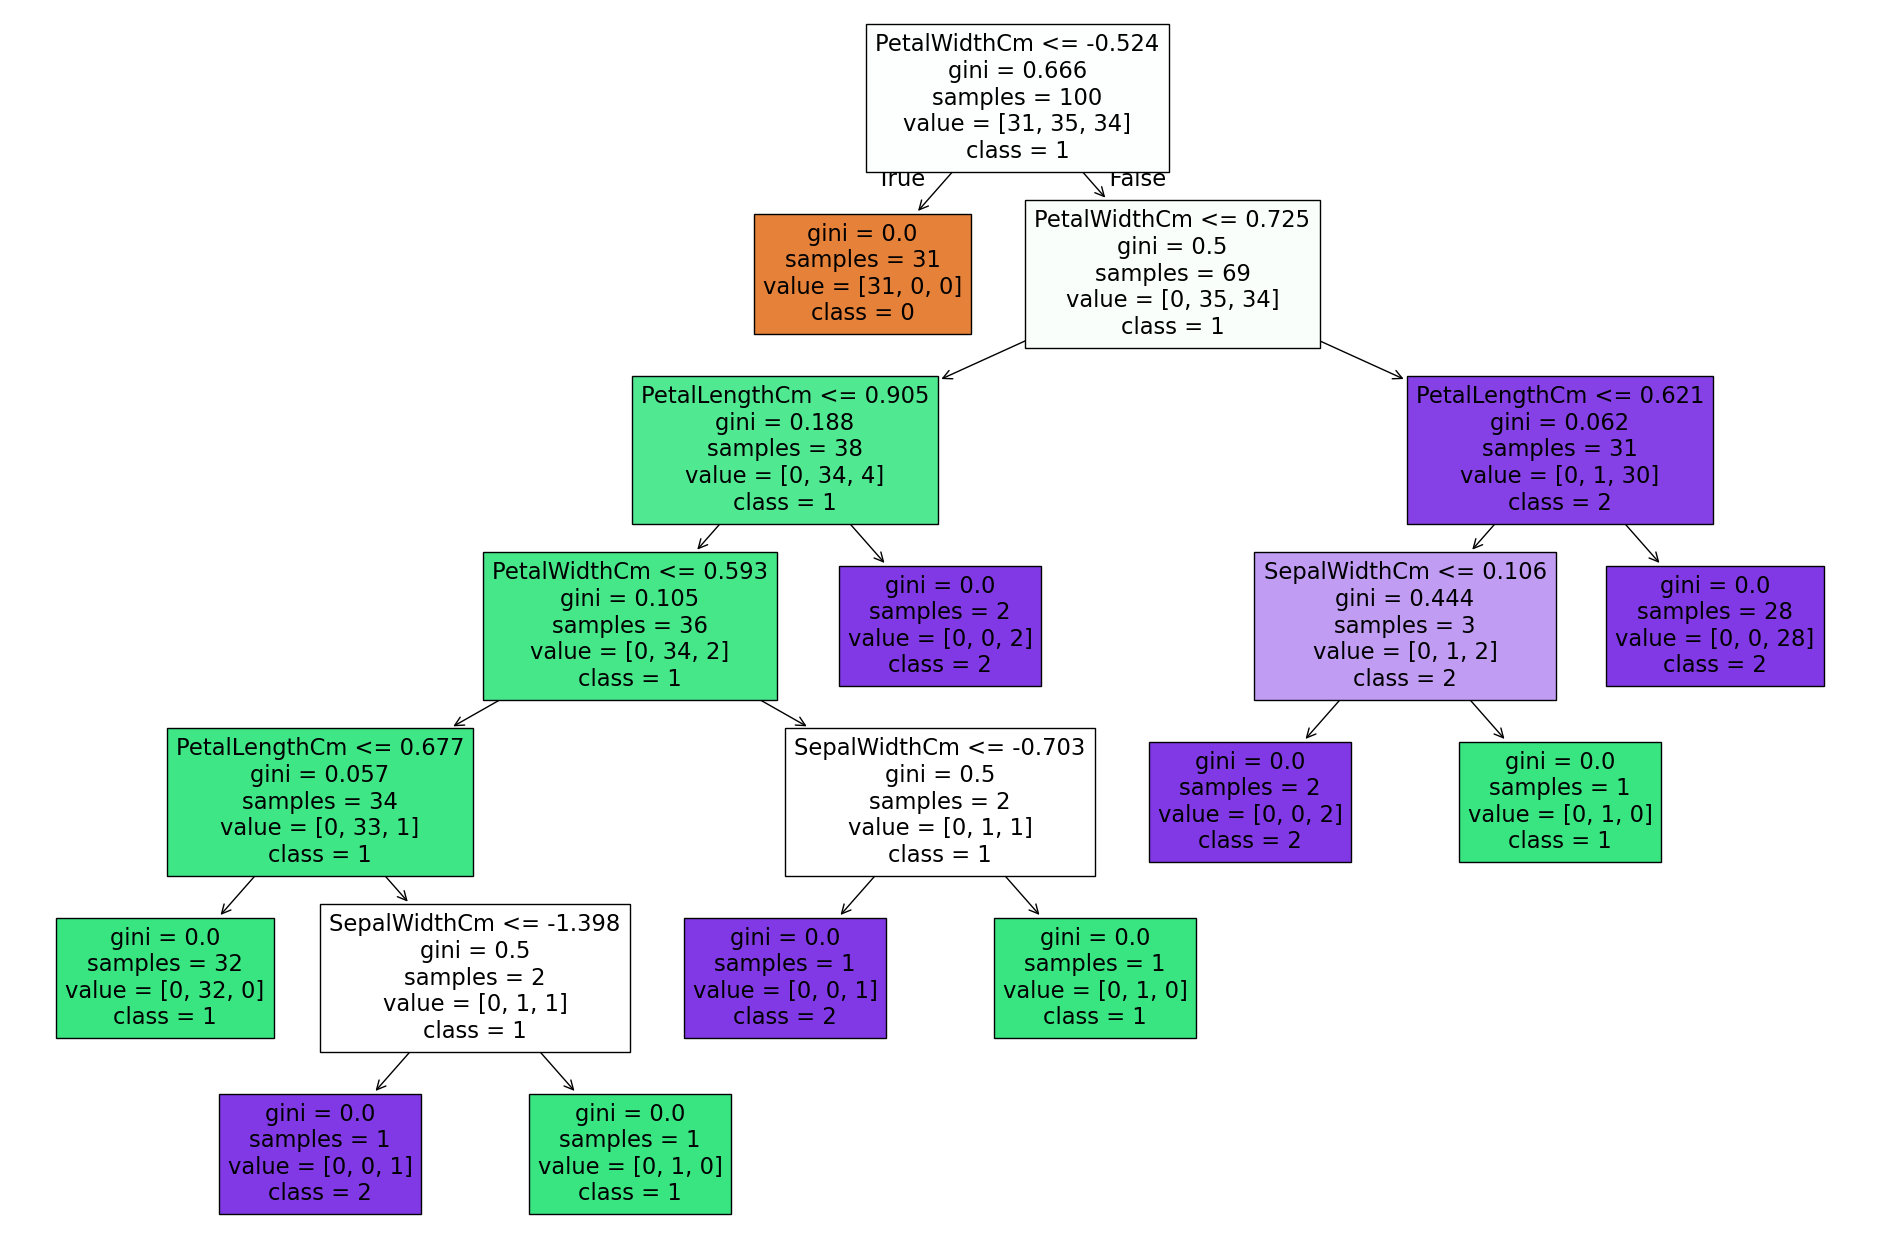

In [50]:
#Plot the tree
from sklearn.tree import export_graphviz

plt.figure(figsize=(24,16))

tree.plot_tree(arbol.fit(X_train, y_train), feature_names=X.columns,
               class_names=['0', '1', '2'], filled=True);

In [ ]:
data_preseleccionado = data[data["PetalWidthCm"]>0.8]

In [ ]:
data_preseleccionado["Species"].value_counts()

Species
1    50
2    50
Name: count, dtype: int64

# XGBoost

In [51]:
import xgboost as xgb
# conda install -c anaconda py-xgboost

In [52]:
modelo = xgb.XGBClassifier(base_score=0.5,
                           colsample_bylevel=1,
                           colsample_bytree=1,
                           gamma=0,
                           learning_rate=0.05,
                           max_delta_step=0,
                           max_depth=5,
                           min_child_weight=1,
                           missing=1,
                           n_estimators=1000,
                           objective='binary:logistic',
                           reg_alpha=0,
                           reg_lambda=1,
                           scale_pos_weight=1,
                           seed=0,
                           verbosity=0,
                           subsample=1)

In [53]:
XGBoost = modelo.fit(X_train, y_train)
y_pred = XGBoost.predict(X_test)
accuracy_score(y_test, y_pred)

0.98

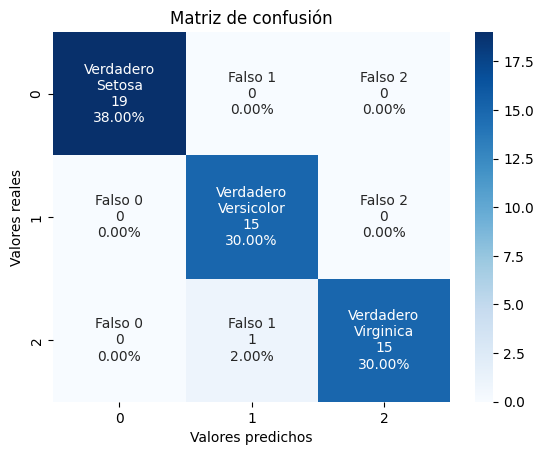

In [54]:
cuadro_matriz_confusion(y_test, y_pred)